In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import numpy as np
import scipy.stats as stats

In [2]:
def ks_test_plot(data1, data2,name1,name2,metric):
    ks_stat, p_value = stats.ks_2samp(data1, data2)

    # 3. Print the results beautifully
    print("--- KS Test Results ---")
    print(f"KS Statistic (D) : {ks_stat:.4f}")
    print(f"P-value          : {p_value:.4e}")
    # Interpret based on a standard 0.05 alpha level
    alpha = 0.05
    if p_value < alpha:
        print("Result           : Reject null hypothesis (Distributions are significantly different)")
    else:
        print("Result           : Fail to reject null hypothesis (Distributions are identical)")

    # 4. Plot the eCDFs
    plt.figure(figsize=(10, 6))

    # Plot the cumulative distributions
    plt.hist(data1, bins=200, density=True, histtype='step', 
            cumulative=True, label=f'{name1} (eCDF)', color='blue', linewidth=2)
    plt.hist(data2, bins=200, density=True, histtype='step', 
            cumulative=True, label=f'{name2} (eCDF)', color='red', linewidth=2)

    # Visually highlight the KS statistic (maximum distance)
    # Find the range to evaluate the vertical line
    min_val = min(np.min(data1), np.min(data2))
    max_val = max(np.max(data1), np.max(data2))
    values = np.linspace(min_val, max_val, 1000)

    cdf1 = np.searchsorted(np.sort(data1), values, side='right') / len(data1)
    cdf2 = np.searchsorted(np.sort(data2), values, side='right') / len(data2)

    d_index = np.argmax(np.abs(cdf1 - cdf2))
    plt.vlines(values[d_index], cdf1[d_index], cdf2[d_index], 
            color='green', linestyle='--', linewidth=2, 
            label=f'KS Statistic (Max Distance = {ks_stat:.4f})')

    plt.title(f'KS Test: Empirical Cumulative Distribution Functions (eCDF) of {metric}')
    plt.xlabel('Values')
    plt.ylabel('Cumulative Probability')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()

def ks_df(seeds):
    ks = [[] for i in seeds]
    temp = 0

    for i in range(len(seeds)):
        for temp in range(len(seeds)):
            data1 = seeds[i]
            data2 = seeds[temp]

            ks_stat, p_value = stats.ks_2samp(data1, data2)
            ks[i].append(ks_stat)

    ks = pd.DataFrame(ks,columns=range(len(seeds)))
        
    return ks


In [3]:
# univariate statistics
max_steps = 100000
step_size = 1000

ts = [x * step_size for x in range(1, int(max_steps/step_size) + 1)]

In [4]:
df = pd.read_csv("./NC_Markov_stats_100000/chain_outputs_0_1000.csv")

for t in ts[1:]:
    dftemp = pd.read_csv(f"./NC_Markov_stats_100000/chain_outputs_0_{t}.csv")
    df = pd.concat([df, dftemp], ignore_index=True)

df1 = pd.read_csv("./NC_Markov_stats_100000/chain_outputs_1_1000.csv")

for t in ts[1:]:
    dftemp = pd.read_csv(f"./NC_Markov_stats_100000/chain_outputs_1_{t}.csv")
    df1 = pd.concat([df1, dftemp], ignore_index=True)

df2 = pd.read_csv("./NC_Markov_stats_100000/chain_outputs_2_1000.csv")

for t in ts[1:]:
    dftemp = pd.read_csv(f"./NC_Markov_stats_100000/chain_outputs_2_{t}.csv")
    df2 = pd.concat([df2, dftemp], ignore_index=True)

df3 = pd.read_csv("./NC_Markov_stats_100000/chain_outputs_3_1000.csv")

for t in ts[1:]:
    dftemp = pd.read_csv(f"./NC_Markov_stats_100000/chain_outputs_3_{t}.csv")
    df3 = pd.concat([df3, dftemp], ignore_index=True)

df4 = pd.read_csv("./NC_Markov_stats_100000/chain_outputs_4_1000.csv")

for t in ts[1:]:
    dftemp = pd.read_csv(f"./NC_Markov_stats_100000/chain_outputs_4_{t}.csv")
    df4 = pd.concat([df4, dftemp], ignore_index=True)

df5 = pd.read_csv("./NC_Markov_stats_100000/chain_outputs_5_1000.csv")

for t in ts[1:]:
    dftemp = pd.read_csv(f"./NC_Markov_stats_100000/chain_outputs_5_{t}.csv")
    df5 = pd.concat([df5, dftemp], ignore_index=True)

df_al = pd.read_csv("./Redist Analysis/NC_ALARM_Ensemble_stats/chain_outputs.csv")

ParserError: Error tokenizing data. C error: Expected 3 fields in line 6, saw 4


In [ ]:
egs = [df['EG'].dropna().to_numpy(),
       df1['EG'].dropna().to_numpy(),
       df2['EG'].dropna().to_numpy(),
       df3['EG'].dropna().to_numpy(),
       df4['EG'].dropna().to_numpy(),
       df5['EG'].dropna().to_numpy(),
       df_al['egs'].dropna().to_numpy()]

ks_tests.append(ks_df(egs))

In [ ]:
ks_tests = []
egs = [df['EG'].dropna().to_numpy(),
       df1['EG'].dropna().to_numpy(),
       df2['EG'].dropna().to_numpy(),
       df3['EG'].dropna().to_numpy(),
       df4['EG'].dropna().to_numpy(),
       df5['EG'].dropna().to_numpy(),
       df_alarm['egs'].dropna().to_numpy()]

ks_tests.append(ks_df(egs))

--- KS Test Results ---
KS Statistic (D) : 0.0009
P-value          : 1.0000e+00
Result           : Fail to reject null hypothesis (Distributions are identical)


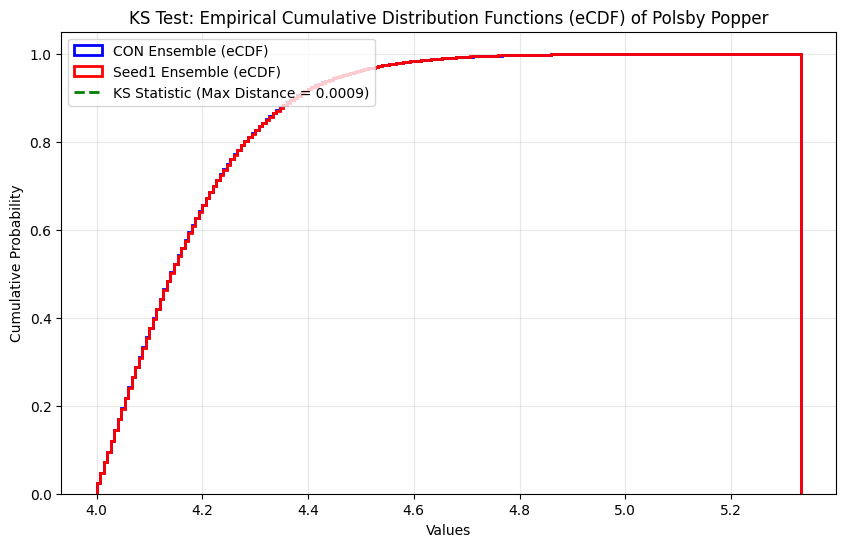

In [61]:
ks_test_plot(df['PP'].dropna().to_numpy(),df_seed1['PP'].dropna().to_numpy(),"CON Ensemble","Seed1 Ensemble", "Polsby Popper")

--- KS Test Results ---
KS Statistic (D) : 0.0020
P-value          : 9.8395e-01
Result           : Fail to reject null hypothesis (Distributions are identical)


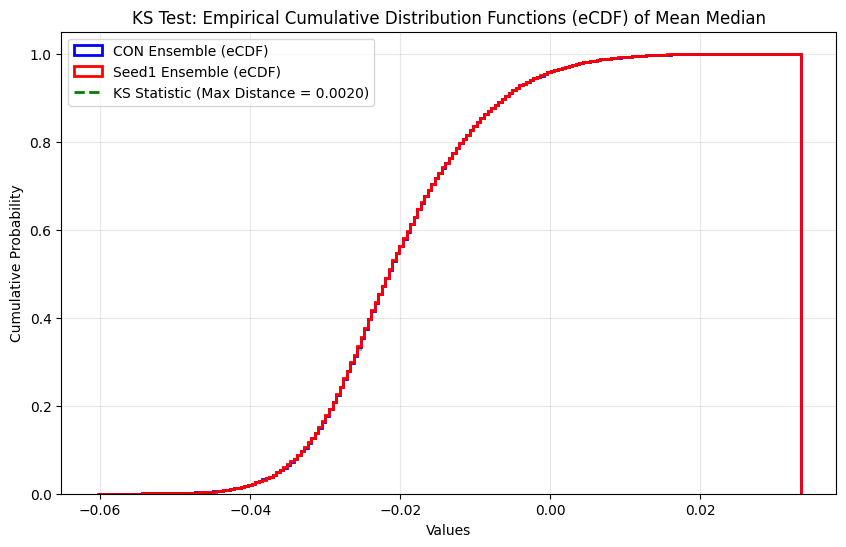

In [62]:
ks_test_plot(df['MM'].dropna().to_numpy(),df_seed1['MM'].dropna().to_numpy(),"CON Ensemble","Seed1 Ensemble", "Mean Median")


In [26]:
df.keys()

Index(['Unnamed: 0', 'County splits', 'MM', 'EG', 'PB', 'DWins', 'PP'], dtype='object')

--- KS Test Results ---
KS Statistic (D) : 0.0009
P-value          : 1.0000e+00
Result           : Fail to reject null hypothesis (Distributions are identical)


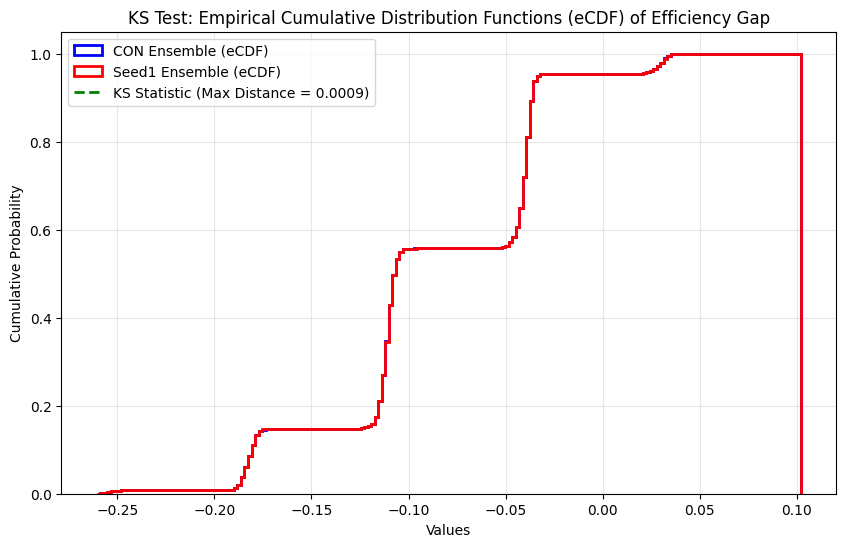

In [63]:
ks_test_plot(df['EG'].dropna().to_numpy(),df_seed1['EG'].dropna().to_numpy(),"CON Ensemble","Seed1 Ensemble", "Efficiency Gap")

--- KS Test Results ---
KS Statistic (D) : 0.0004
P-value          : 1.0000e+00
Result           : Fail to reject null hypothesis (Distributions are identical)


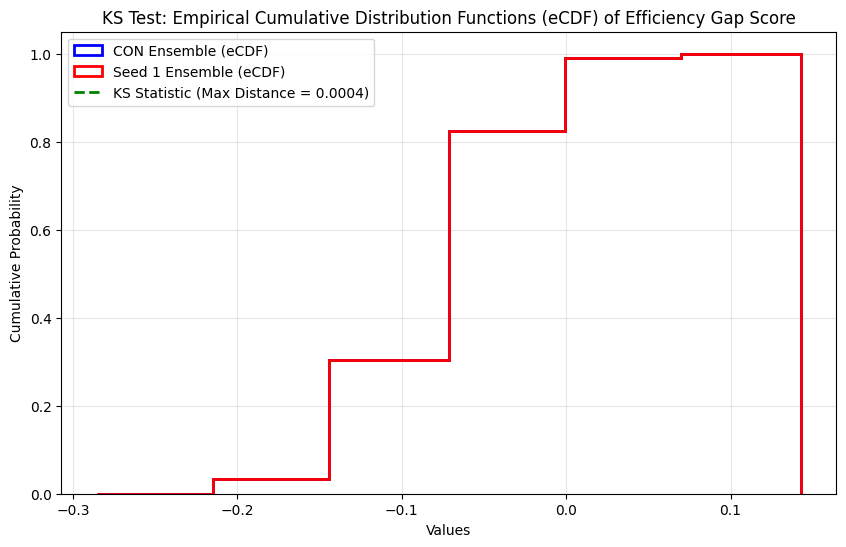

In [ ]:
ks_test_plot(df['PP'].dropna().to_numpy(),df_seed1['PP'].dropna().to_numpy(),"CON Ensemble","Seed1 Ensemble", "Polsby Popper")

--- KS Test Results ---
KS Statistic (D) : 0.0004
P-value          : 1.0000e+00
Result           : Fail to reject null hypothesis (Distributions are identical)


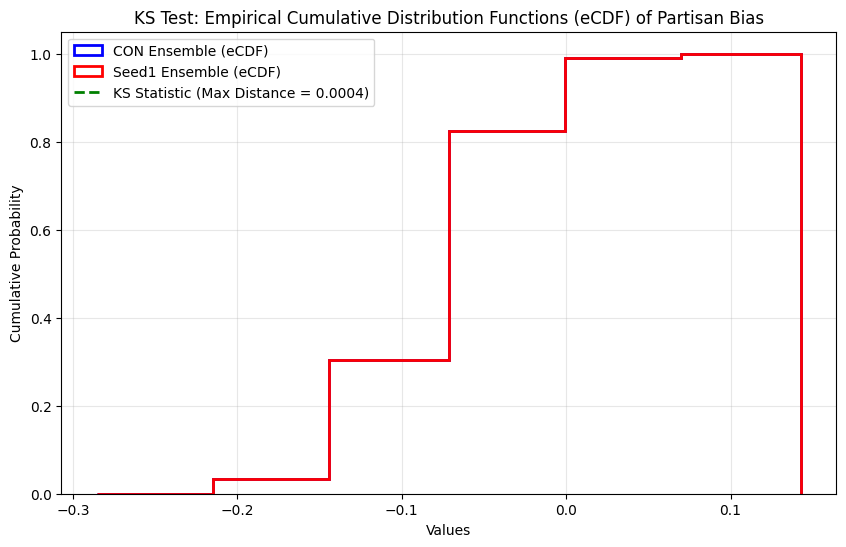

In [64]:
ks_test_plot(df['PB'].dropna().to_numpy(),df_seed1['PB'].dropna().to_numpy(),"CON Ensemble","Seed1 Ensemble", "Partisan Bias")

--- KS Test Results ---
KS Statistic (D) : 0.0002
P-value          : 1.0000e+00
Result           : Fail to reject null hypothesis (Distributions are identical)


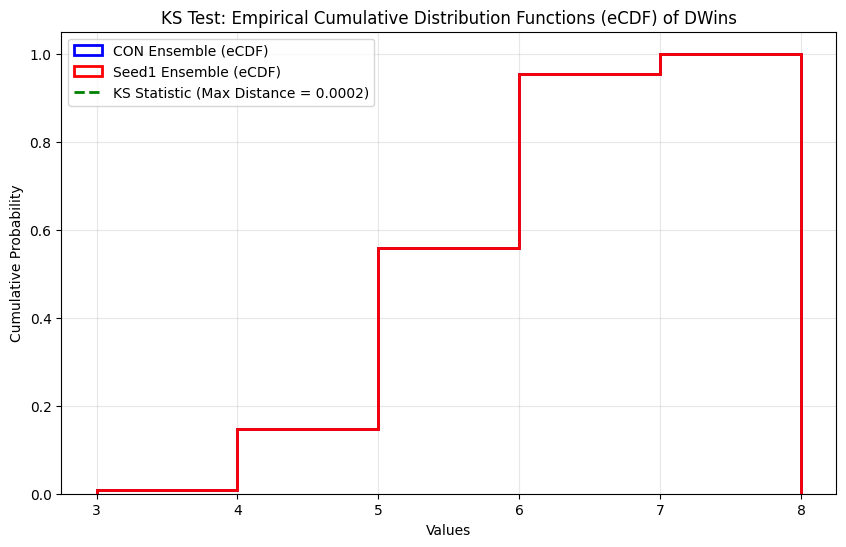

In [65]:
ks_test_plot(df['DWins'].dropna().to_numpy(),df_seed1['DWins'].dropna().to_numpy(),"CON Ensemble","Seed1 Ensemble", "DWins")

In [19]:
counts = Counter(df['County splits'])

categories = list(counts.keys())
frequencies = list(counts.values())
plt.bar(categories, frequencies)
plt.axvline(11, color='red',label='Enacted')
plt.title("County splits")
plt.savefig('./NC_Markov_stats_100000/graphs/cs.png')
plt.close()

plt.hist(df['MM'],bins=100)
plt.axvline(-0.05668032542711077, color='red',label='Enacted')
plt.title("Mean median")
plt.savefig('./NC_Markov_stats_100000/graphs/mm.png')
plt.close()

plt.hist(df['EG'],bins=100)
plt.axvline(-0.25611450640053, color='red',label='Enacted')
plt.title("Efficiency gap")
plt.savefig('./NC_Markov_stats_100000/graphs/eg.png')
plt.close()

plt.hist(df['PB'])
plt.axvline(-0.2857142857142857, color='red',label='Enacted')
plt.title("Partisan bias")
plt.savefig('./NC_Markov_stats_100000/graphs/pb.png')
plt.close()

plt.hist(df['PP'],bins=100)
plt.axvline(4.17002956008203, color='red',label='Enacted')
plt.title("Polsby popper")
plt.savefig('./NC_Markov_stats_100000/graphs/pp.png')
plt.close()

counts2 = Counter(df['DWins'])

categories = list(counts2.keys())
frequencies = list(counts2.values())

plt.bar(categories, frequencies)
plt.axvline(3, color='red',label='Enacted')
plt.title("Dem wins")
plt.savefig('./NC_Markov_stats_100000/graphs/dwins.png')
plt.close()

In [5]:
con_dempercs = []

for t in ts:
    tempvotes=np.loadtxt(f"./NC_Markov_stats_100000/DemPercs_0_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        con_dempercs.append(tempvotes[s,:])

con_dempercs = np.array(con_dempercs)

medianprops = dict(color='black')

c_con="tab:blue"

In [7]:
lowest_con_dempercs = np.min(con_dempercs,axis=1)
lowest_con_dempercs

array([0.4015134 , 0.32057113, 0.32057113, ..., 0.33203196, 0.33203196,
       0.33203196])

In [30]:
seed1_dempercs = []

for t in ts:
    tempvotes=np.loadtxt(f"./NC_Markov_stats_100000/DemPercs_1_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        seed1_dempercs.append(tempvotes[s,:])

seed1_dempercs = np.array(seed1_dempercs)

medianprops = dict(color='black')

c_1="tab:green"

In [8]:
lowest_seed1_dempercs = np.min(seed1_dempercs,axis=1)
lowest_seed1_dempercs

array([0.28733227, 0.28733227, 0.28733227, ..., 0.38825854, 0.38825854,
       0.31530758])

--- KS Test Results ---
KS Statistic (D) : 0.0231
P-value          : 1.7160e-23
Result           : Reject null hypothesis (Distributions are significantly different)


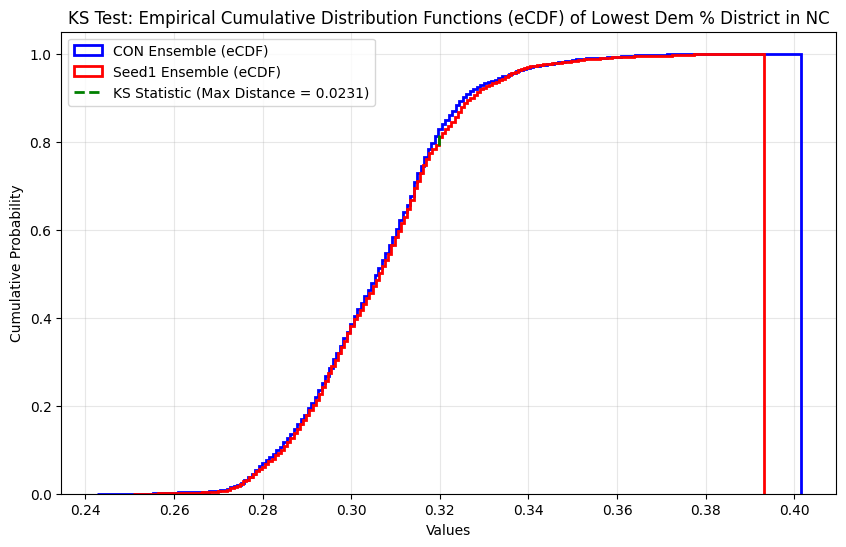

In [66]:
ks_test_plot(lowest_con_dempercs,lowest_seed1_dempercs,"CON Ensemble","Seed1 Ensemble", "Lowest Dem % District in NC")

In [9]:
seed2_dempercs = []

for t in ts:
    tempvotes=np.loadtxt(f"./NC_Markov_stats_100000/DemPercs_2_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        seed2_dempercs.append(tempvotes[s,:])

seed2_dempercs = np.array(seed2_dempercs)

medianprops = dict(color='black')

c_2="tab:orange"

In [10]:
seed3_dempercs = []

for t in ts:
    tempvotes=np.loadtxt(f"./NC_Markov_stats_100000/DemPercs_3_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        seed3_dempercs.append(tempvotes[s,:])

seed3_dempercs = np.array(seed3_dempercs)

medianprops = dict(color='black')

c_3="tab:red"

In [11]:
seed4_dempercs = []

for t in ts:
    tempvotes=np.loadtxt(f"./NC_Markov_stats_100000/DemPercs_4_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        seed4_dempercs.append(tempvotes[s,:])

seed4_dempercs = np.array(seed4_dempercs)

medianprops = dict(color='black')

c_4="tab:brown"

In [12]:
seed5_dempercs = []

for t in ts:
    tempvotes=np.loadtxt(f"./NC_Markov_stats_100000/DemPercs_5_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        seed5_dempercs.append(tempvotes[s,:])

seed5_dempercs = np.array(seed5_dempercs)

medianprops = dict(color='black')

c_5="tab:cyan"

In [13]:
alarm_dempercs = []

tempvotes=np.loadtxt(f"./Redist Analysis/NC_ALARM_Ensemble_Stats/DemPercs.csv", delimiter=",")
for s in range(5000):
    alarm_dempercs.append(tempvotes[s,:])

alarm_dempercs = np.array(alarm_dempercs)

medianprops = dict(color='black')

c_al="tab:purple"

In [14]:
lowest_alarm_dempercs = np.min(alarm_dempercs,axis=1)
lowest_alarm_dempercs

array([0.2922544 , 0.32197236, 0.2922544 , ..., 0.35025856, 0.30750278,
       0.29761526])

In [76]:
alarm_dempercs2 = []

tempvotes=np.loadtxt(f"./Redist Analysis/NC_ALARM_Ensemble_Stats/DemPercs2.csv", delimiter=",")
for s in range(5000):
    alarm_dempercs2.append(tempvotes[s,:])

alarm_dempercs2 = np.array(alarm_dempercs2)

medianprops = dict(color='black')

c_al="tab:purple"

lowest_alarm2_dempercs = np.min(alarm_dempercs2,axis=1)

--- KS Test Results ---
KS Statistic (D) : 0.1448
P-value          : 4.1289e-46
Result           : Reject null hypothesis (Distributions are significantly different)


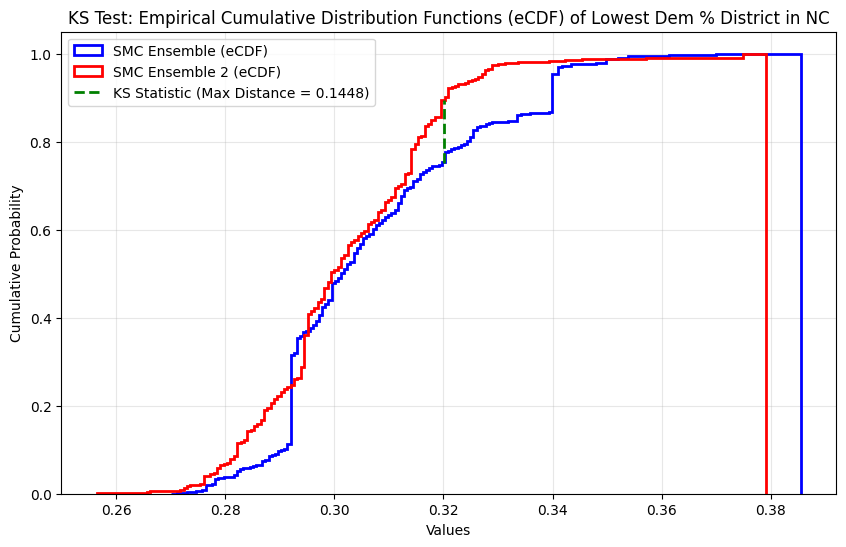

In [78]:
ks_test_plot(lowest_alarm_dempercs,lowest_alarm2_dempercs,"SMC Ensemble","SMC Ensemble 2", "Lowest Dem % District in NC")

In [15]:
for list in con_dempercs:
    list.sort()

for list in seed1_dempercs:
    list.sort()

for list in seed2_dempercs:
    list.sort()

for list in seed3_dempercs:
    list.sort()

for list in seed4_dempercs:
    list.sort()

for list in seed5_dempercs:
    list.sort()

In [16]:
d_percs = [con_dempercs, seed1_dempercs, seed2_dempercs, seed3_dempercs, seed4_dempercs, seed5_dempercs]

for d in d_percs:
    d = np.array(d)

In [17]:
final_ks_dem = []
for dist in range(14):
    dist_percents = []
    for i in range(len(d_percs)):
        for j in range(i, len(d_percs)):
            dist_percents.append(stats.ks_2samp(d_percs[i][:, dist], d_percs[j][:, dist])[0])

    final_ks_dem.append(sum(dist_percents)/len(dist_percents))

In [20]:
final_ks_dem = pd.DataFrame(final_ks_dem)

final_ks_dem

,0
0,0.016498
1,0.029980
2,0.025927
3,0.026741
4,0.016794
5,0.023169
6,0.019290
7,0.017508
8,0.020381
9,0.020362


Text(0.5, 1.0, 'NC Districts % Democratic')

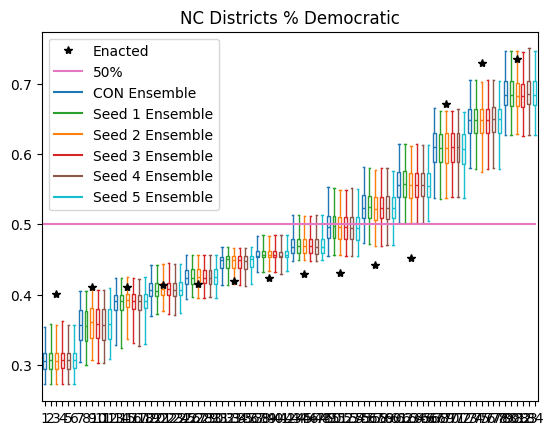

In [13]:
plt.boxplot(
    con_dempercs,
    positions=[1, 7, 13, 19, 25, 31, 37, 43, 49, 55, 61, 67, 73, 79],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_con),
    capprops=dict(color=c_con),
    whiskerprops=dict(color=c_con),
    flierprops=dict(color=c_con,markeredgecolor=c_con),
    medianprops=dict(color=c_con)
)

plt.boxplot(
    seed1_dempercs,
    positions=[2, 8, 14, 20, 26, 32, 38, 44, 50, 56, 62, 68, 74, 80],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_1),
    capprops=dict(color=c_1),
    whiskerprops=dict(color=c_1),
    flierprops=dict(color=c_1,markeredgecolor=c_1),
    medianprops=dict(color=c_1)
)

plt.boxplot(
    seed2_dempercs,
    positions=[3, 9, 15, 21, 27, 33, 39, 45, 51, 57, 63, 69, 75, 81],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_2),
    capprops=dict(color=c_2),
    whiskerprops=dict(color=c_2),
    flierprops=dict(color=c_2,markeredgecolor=c_2),
    medianprops=dict(color=c_2)
)

plt.boxplot(
    seed3_dempercs,
    positions=[4, 10, 16, 22, 28, 34, 40, 46, 52, 58, 64, 70, 76, 82],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_3),
    capprops=dict(color=c_3),
    whiskerprops=dict(color=c_3),
    flierprops=dict(color=c_3,markeredgecolor=c_3),
    medianprops=dict(color=c_3)
)

plt.boxplot(
    seed4_dempercs,
    positions=[5, 11, 17, 23, 29, 35, 41, 47, 53, 59, 65, 71, 77, 83],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_4),
    capprops=dict(color=c_4),
    whiskerprops=dict(color=c_4),
    flierprops=dict(color=c_4,markeredgecolor=c_4),
    medianprops=dict(color=c_4)
)

plt.boxplot(
    seed5_dempercs,
    positions=[6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72, 78, 84],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_5),
    capprops=dict(color=c_5),
    whiskerprops=dict(color=c_5),
    flierprops=dict(color=c_5,markeredgecolor=c_5),
    medianprops=dict(color=c_5)
)

plt.plot([3, 9, 15, 21, 27, 33, 39, 45, 51, 57, 63, 69, 75, 81],
         sorted([0.41886754221788536,0.4102550692587003,0.4015134041175902,0.4518196604772827,0.44262948889535925,0.42972030525431776,0.42424257414722344,0.41316756365141794,0.4152301363495878,0.4105112876315188,0.7289525437627258,0.4301783057905161,0.7353109186481949,0.6714747293927874]),
         "*",color="k",label="Enacted")

plt.plot([0.5,84],[0.5,0.5],color="tab:pink",label="50%")
plt.plot([],[],color='tab:blue',label='CON Ensemble')
plt.plot([],[],color='tab:green',label='Seed 1 Ensemble')
plt.plot([],[],color='tab:orange',label='Seed 2 Ensemble')
plt.plot([],[],color='tab:red',label='Seed 3 Ensemble')
plt.plot([],[],color='tab:brown',label='Seed 4 Ensemble')
plt.plot([],[],color='tab:cyan',label='Seed 5 Ensemble')
plt.legend()
plt.title("NC Districts % Democratic")

Text(0.5, 1.0, 'NC Districts % Democratic')

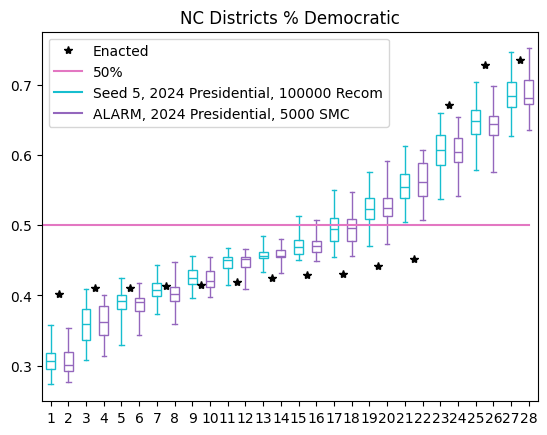

In [14]:
plt.boxplot(
    seed5_dempercs,
    positions=[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_5),
    capprops=dict(color=c_5),
    whiskerprops=dict(color=c_5),
    flierprops=dict(color=c_5,markeredgecolor=c_5),
    medianprops=dict(color=c_5)
)

plt.boxplot(
    alarm_dempercs,
    positions=[2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_al),
    capprops=dict(color=c_al),
    whiskerprops=dict(color=c_al),
    flierprops=dict(color=c_al,markeredgecolor=c_al),
    medianprops=dict(color=c_al)
)

plt.plot([1.5, 3.5, 5.5, 7.5, 9.5, 11.5, 13.5, 15.5, 17.5, 19.5, 21.5, 23.5, 25.5, 27.5],
         sorted([0.41886754221788536,0.4102550692587003,0.4015134041175902,0.4518196604772827,0.44262948889535925,0.42972030525431776,0.42424257414722344,0.41316756365141794,0.4152301363495878,0.4105112876315188,0.7289525437627258,0.4301783057905161,0.7353109186481949,0.6714747293927874]),
         "*",color="k",label="Enacted")

plt.plot([0.5,28],[0.5,0.5],color="tab:pink",label="50%")
plt.plot([],[],color='tab:cyan',label='Seed 5, 2024 Presidential, 100000 Recom')
plt.plot([],[],color='tab:purple',label='ALARM, 2024 Presidential, 5000 SMC')
plt.legend()
plt.title("NC Districts % Democratic")

Text(0.5, 1.0, 'NC Districts % Black')

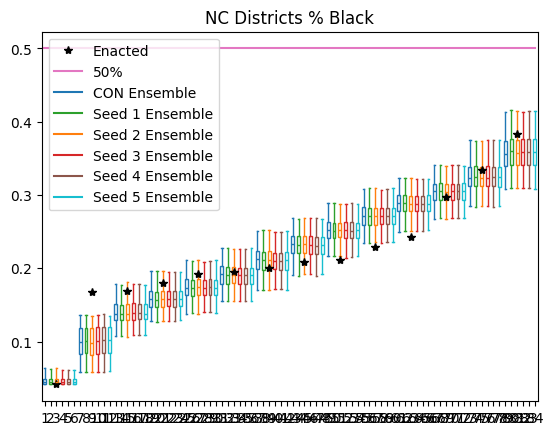

In [18]:
con_blackpercs = []

for t in ts:
    tempvotes=np.loadtxt(f"./NC_Markov_stats_100000/BlackPercs_0_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        con_blackpercs.append(tempvotes[s,:])

con_blackpercs = np.array(con_blackpercs)

medianprops = dict(color='black')

c_con="tab:blue"

seed1_blackpercs = []

for t in ts:
    tempvotes=np.loadtxt(f"./NC_Markov_stats_100000/BlackPercs_1_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        seed1_blackpercs.append(tempvotes[s,:])

seed1_blackpercs = np.array(seed1_blackpercs)

medianprops = dict(color='black')

c_1="tab:green"

seed2_blackpercs = []

for t in ts:
    tempvotes=np.loadtxt(f"./NC_Markov_stats_100000/BlackPercs_2_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        seed2_blackpercs.append(tempvotes[s,:])

seed2_blackpercs = np.array(seed2_blackpercs)

medianprops = dict(color='black')

c_2="tab:orange"

seed3_blackpercs = []

for t in ts:
    tempvotes=np.loadtxt(f"./NC_Markov_stats_100000/BlackPercs_3_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        seed3_blackpercs.append(tempvotes[s,:])

seed3_blackpercs = np.array(seed3_blackpercs)

medianprops = dict(color='black')

c_3="tab:red"

seed4_blackpercs = []

for t in ts:
    tempvotes=np.loadtxt(f"./NC_Markov_stats_100000/BlackPercs_4_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        seed4_blackpercs.append(tempvotes[s,:])

seed4_blackpercs = np.array(seed4_blackpercs)

medianprops = dict(color='black')

c_4="tab:brown"

seed5_blackpercs = []

for t in ts:
    tempvotes=np.loadtxt(f"./NC_Markov_stats_100000/BlackPercs_5_{t}.csv", delimiter=",")
    for s in range(step_size-1):
        seed5_blackpercs.append(tempvotes[s,:])

seed5_blackpercs = np.array(seed5_blackpercs)

medianprops = dict(color='black')

c_5="tab:cyan"

alarm_blackpercs = []

tempvotes=np.loadtxt(f"./Redist Analysis/NC_ALARM_Ensemble_Stats/BlackPerc.csv", delimiter=",")
for s in range(5000):
    alarm_blackpercs.append(tempvotes[s,:])

alarm_blackpercs = np.array(alarm_blackpercs)

medianprops = dict(color='black')

c_al="tab:purple"

plt.boxplot(
    con_blackpercs,
    positions=[1, 7, 13, 19, 25, 31, 37, 43, 49, 55, 61, 67, 73, 79],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_con),
    capprops=dict(color=c_con),
    whiskerprops=dict(color=c_con),
    flierprops=dict(color=c_con,markeredgecolor=c_con),
    medianprops=dict(color=c_con)
)

plt.boxplot(
    seed1_blackpercs,
    positions=[2, 8, 14, 20, 26, 32, 38, 44, 50, 56, 62, 68, 74, 80],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_1),
    capprops=dict(color=c_1),
    whiskerprops=dict(color=c_1),
    flierprops=dict(color=c_1,markeredgecolor=c_1),
    medianprops=dict(color=c_1)
)

plt.boxplot(
    seed2_blackpercs,
    positions=[3, 9, 15, 21, 27, 33, 39, 45, 51, 57, 63, 69, 75, 81],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_2),
    capprops=dict(color=c_2),
    whiskerprops=dict(color=c_2),
    flierprops=dict(color=c_2,markeredgecolor=c_2),
    medianprops=dict(color=c_2)
)

plt.boxplot(
    seed3_blackpercs,
    positions=[4, 10, 16, 22, 28, 34, 40, 46, 52, 58, 64, 70, 76, 82],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_3),
    capprops=dict(color=c_3),
    whiskerprops=dict(color=c_3),
    flierprops=dict(color=c_3,markeredgecolor=c_3),
    medianprops=dict(color=c_3)
)

plt.boxplot(
    seed4_blackpercs,
    positions=[5, 11, 17, 23, 29, 35, 41, 47, 53, 59, 65, 71, 77, 83],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_4),
    capprops=dict(color=c_4),
    whiskerprops=dict(color=c_4),
    flierprops=dict(color=c_4,markeredgecolor=c_4),
    medianprops=dict(color=c_4)
)

plt.boxplot(
    seed5_blackpercs,
    positions=[6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72, 78, 84],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_5),
    capprops=dict(color=c_5),
    whiskerprops=dict(color=c_5),
    flierprops=dict(color=c_5,markeredgecolor=c_5),
    medianprops=dict(color=c_5)
)


plt.plot([3, 9, 15, 21, 27, 33, 39, 45, 51, 57, 63, 69, 75, 81],sorted([0.22942044041576282,
 0.19229480241029692,
 0.17956793200417584,
 0.04239387124357679,
 0.3343947666604468,
 0.2090103932041959,
 0.16776705580854165,
 0.20011859792092224,
 0.19469551364130155,
 0.1695334362636302,
 0.2111577988153698,
 0.29668742389424085,
 0.38389802664664036,
 0.24333683400032827]),"*",color="k",label="Enacted")

plt.plot([0.5,84],[0.5,0.5],color="tab:pink",label="50%")

plt.plot([],[],color='tab:blue',label='CON Ensemble')
plt.plot([],[],color='tab:green',label='Seed 1 Ensemble')
plt.plot([],[],color='tab:orange',label='Seed 2 Ensemble')
plt.plot([],[],color='tab:red',label='Seed 3 Ensemble')
plt.plot([],[],color='tab:brown',label='Seed 4 Ensemble')
plt.plot([],[],color='tab:cyan',label='Seed 5 Ensemble')
plt.legend()
plt.title("NC Districts % Black")

Text(0.5, 1.0, 'NC Districts % Black')

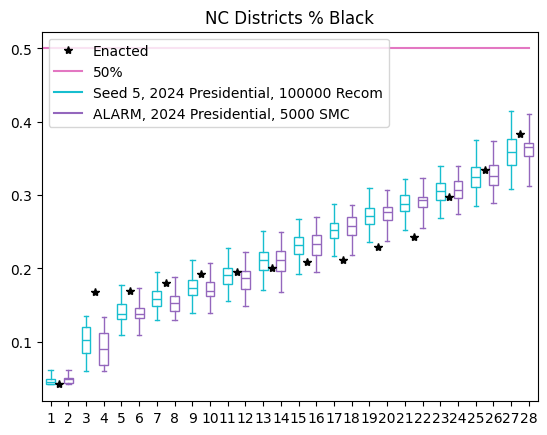

In [5]:
plt.boxplot(
    seed5_blackpercs,
    positions=[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_5),
    capprops=dict(color=c_5),
    whiskerprops=dict(color=c_5),
    flierprops=dict(color=c_5,markeredgecolor=c_5),
    medianprops=dict(color=c_5)
)

plt.boxplot(
    alarm_blackpercs,
    positions=[2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28],
    whis=[1,99],
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="None", color=c_al),
    capprops=dict(color=c_al),
    whiskerprops=dict(color=c_al),
    flierprops=dict(color=c_al,markeredgecolor=c_al),
    medianprops=dict(color=c_al)
)

plt.plot([1.5, 3.5, 5.5, 7.5, 9.5, 11.5, 13.5, 15.5, 17.5, 19.5, 21.5, 23.5, 25.5, 27.5], sorted([0.22942044041576282,
 0.19229480241029692,
 0.17956793200417584,
 0.04239387124357679,
 0.3343947666604468,
 0.2090103932041959,
 0.16776705580854165,
 0.20011859792092224,
 0.19469551364130155,
 0.1695334362636302,
 0.2111577988153698,
 0.29668742389424085,
 0.38389802664664036,
 0.24333683400032827]),"*",color="k",label="Enacted")

plt.plot([0.5,28],[0.5,0.5],color="tab:pink",label="50%")
plt.plot([],[],color='tab:cyan',label='Seed 5, 2024 Presidential, 100000 Recom')
plt.plot([],[],color='tab:purple',label='ALARM, 2024 Presidential, 5000 SMC')
plt.legend()
plt.title("NC Districts % Black")

In [49]:
lowest_con_blackpercs = np.min(con_blackpercs,axis=1)
print(lowest_con_blackpercs)

lowest_seed1_blackpercs = np.min(seed1_blackpercs,axis=1)
lowest_seed1_blackpercs

[0.04239387 0.04239387 0.04239387 ... 0.04309685 0.04309685 0.04309685]


array([0.04289413, 0.04289413, 0.04264877, ..., 0.04789961, 0.04789961,
       0.04789961])

--- KS Test Results ---
KS Statistic (D) : 0.0162
P-value          : 8.7695e-12
Result           : Reject null hypothesis (Distributions are significantly different)


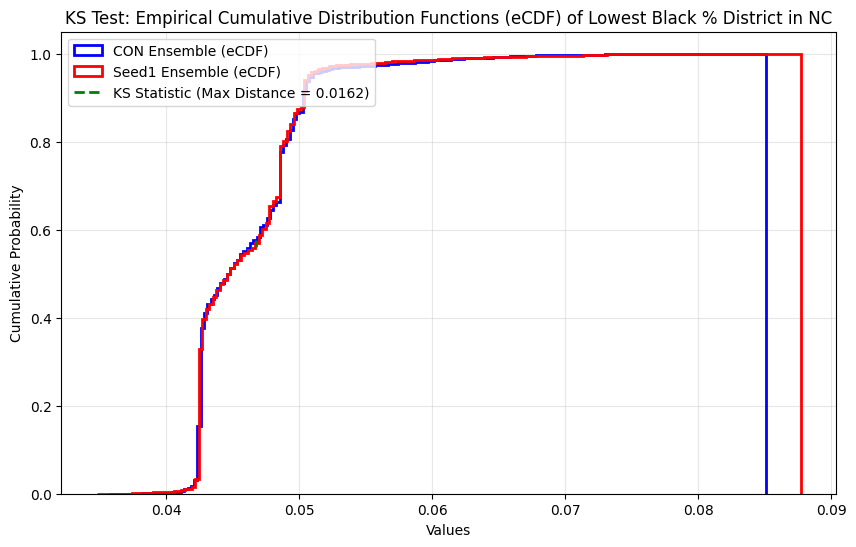

In [68]:
ks_test_plot(lowest_con_blackpercs,lowest_seed1_blackpercs,"CON Ensemble","Seed1 Ensemble", "Lowest Black % District in NC")

In [51]:
lowest_alarm_blackpercs = np.min(alarm_blackpercs,axis=1)
lowest_alarm_blackpercs

array([0.0566536 , 0.04712768, 0.0566536 , ..., 0.04318666, 0.04383449,
       0.05057795])

--- KS Test Results ---
KS Statistic (D) : 0.1147
P-value          : 4.6152e-55
Result           : Reject null hypothesis (Distributions are significantly different)


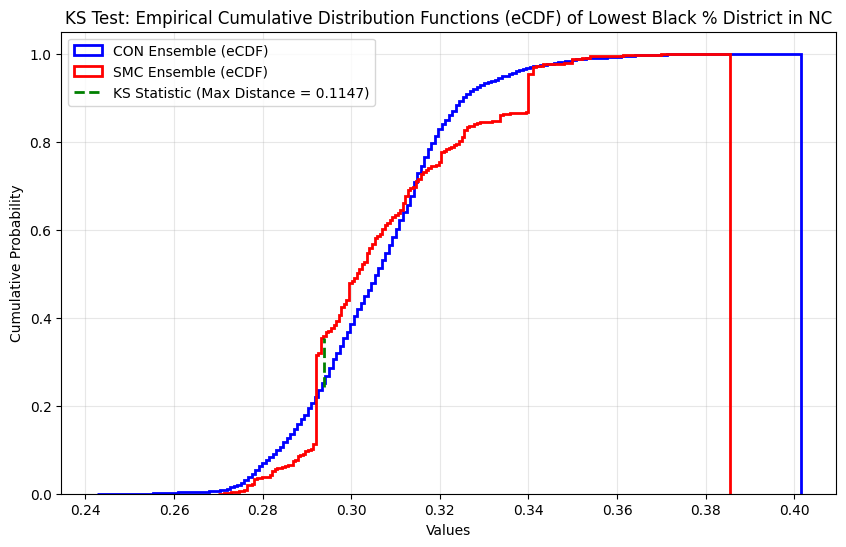

In [69]:
ks_test_plot(lowest_con_dempercs,lowest_alarm_dempercs,"CON Ensemble","SMC Ensemble", "Lowest Black % District in NC")

In [80]:
alarm_black_percs2 = []

tempvotes=np.loadtxt(f"./Redist Analysis/NC_ALARM_Ensemble_Stats/BlackPerc2.csv", delimiter=",")
for s in range(5000):
    alarm_black_percs2.append(tempvotes[s,:])

alarm_black_percs2 = np.array(alarm_black_percs2)

medianprops = dict(color='black')

c_al="tab:purple"

lowest_alarm2_black_percs = np.min(alarm_black_percs2,axis=1)

--- KS Test Results ---
KS Statistic (D) : 0.2246
P-value          : 6.7910e-111
Result           : Reject null hypothesis (Distributions are significantly different)


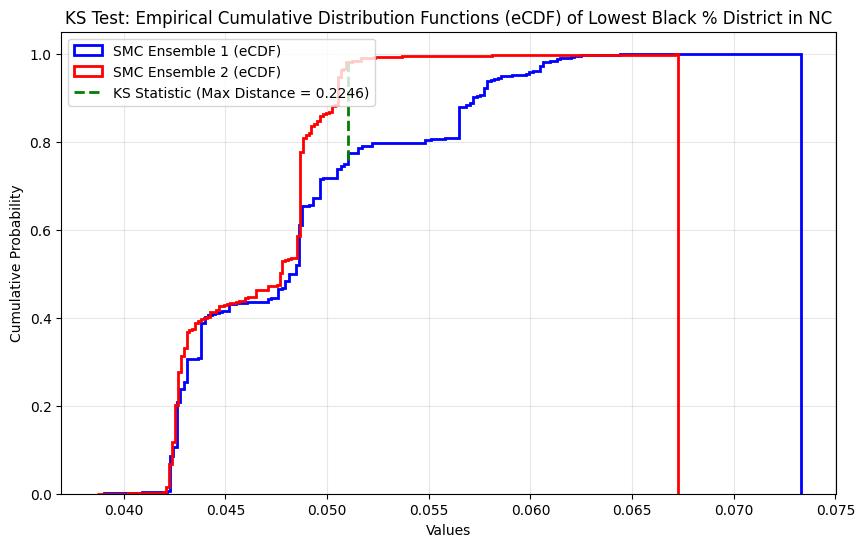

In [81]:
ks_test_plot(lowest_alarm_blackpercs,lowest_alarm2_black_percs,"SMC Ensemble 1","SMC Ensemble 2", "Lowest Black % District in NC")

In [19]:
for list in con_blackpercs:
    list.sort()

for list in seed1_blackpercs:
    list.sort()

for list in seed2_blackpercs:
    list.sort()

for list in seed3_blackpercs:
    list.sort()

for list in seed4_blackpercs:
    list.sort()

for list in seed5_blackpercs:
    list.sort()

for list in alarm_blackpercs:
    list.sort()

In [21]:
b_percs = [con_blackpercs, seed1_blackpercs, seed2_blackpercs, seed3_blackpercs, seed4_blackpercs, seed5_blackpercs]

for b in b_percs:
    b = np.array(b)

In [23]:
final_ks = []
for d in range(14):
    d_percents = []
    for i in range(len(b_percs)):
        for j in range(i, len(b_percs)):
            d_percents.append(stats.ks_2samp(b_percs[i][:, d], b_percs[j][:, d])[0])

    final_ks.append(sum(d_percents)/len(d_percents))

In [24]:
final_ks = pd.DataFrame(final_ks)

final_ks

,0
0,0.018650
1,0.022059
2,0.019122
3,0.016851
4,0.017380
5,0.018686
6,0.023233
7,0.019391
8,0.013396
9,0.013227
